# ECE140 — Introduction Plots

Each code block saves an SVG to `media/` relative to this file. Run cells top-to-bottom; the setup cell must run first.

---

## Setup

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

OUT = Path("media")
OUT.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.size": 12,
    "figure.facecolor": "none",
    "axes.facecolor": "none",
    "text.color": "white",
    "axes.labelcolor": "white",
    "axes.edgecolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "white",
    "grid.alpha": 0.2,
    "legend.edgecolor": "white",
    "legend.labelcolor": "white",
})
SAVE = dict(dpi=300, bbox_inches="tight", transparent=True)

---

## Resistor I–V Characteristic

Linear $I = V/R$ relationship showing Ohm's law.

saved resistor_iv.svg


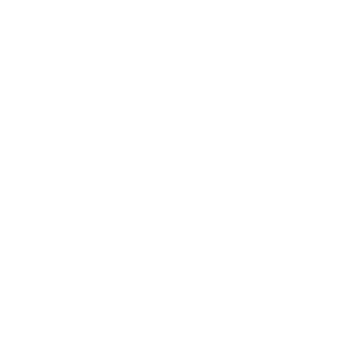

In [1]:
fig, ax = plt.subplots(figsize=(3.5, 3.5))
V = np.linspace(-2, 2, 200)
ax.plot(V, V, color="white", lw=2)

for sp in ("right", "top"):
    ax.spines[sp].set_visible(False)
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
for sp in ("left", "bottom"):
    ax.spines[sp].set_color("white")
ax.set_xlim(-2.3, 2.3)
ax.set_ylim(-2.3, 2.3)
ax.set_xticks([])
ax.set_yticks([])

ax.annotate("", xy=(2.3, 0), xytext=(-2.3, 0),
            arrowprops=dict(arrowstyle="->", color="white", lw=1.2))
ax.annotate("", xy=(0, 2.3), xytext=(0, -2.3),
            arrowprops=dict(arrowstyle="->", color="white", lw=1.2))
ax.text(2.1, -0.2, "$V$", ha="center", fontsize=13, color="white")
ax.text(0.15, 2.1, "$I$", ha="center", fontsize=13, color="white")
ax.text(1.2, 1.85, r"$I=\frac{V}{R}$", fontsize=12, color="white")

fig.tight_layout()
fig.savefig(OUT / "resistor_iv.svg", **SAVE)
print("saved resistor_iv.svg")

---

## Diode I–V Characteristic

Shockley equation $I = I_S(e^{V/V_T} - 1)$ with $V_T = 26\,\text{mV}$ (room temperature). Forward bias in red, reverse bias in blue.

saved diode_iv.svg


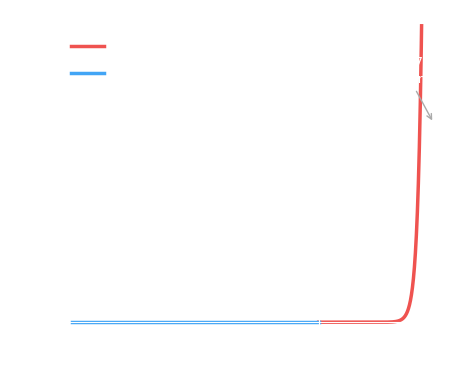

In [1]:
Is = 1e-12
Vt = 0.026

Vf = np.linspace(0, 0.75, 500)
If_mA = Is * (np.exp(Vf / Vt) - 1) * 1000

Vr = np.linspace(-1.5, 0, 200)
Ir_mA = Is * (np.exp(Vr / Vt) - 1) * 1000

fig, ax = plt.subplots(figsize=(4.5, 3.8))
ax.plot(Vf, If_mA, color="#EF5350", lw=2.5, label="Forward bias")
ax.plot(Vr, Ir_mA, color="#42A5F5", lw=2.5, label="Reverse bias")
ax.axhline(0, color="white", lw=0.8)
ax.axvline(0, color="white", lw=0.8)
ax.set_xlim(-1.6, 0.8)
ax.set_ylim(-0.5, 30)
ax.set_xlabel("$V$ [V]")
ax.set_ylabel("$I$ [mA]")
ax.set_title("Diode $I$–$V$ Characteristic")
ax.legend(loc="upper left")
ax.grid(True)
ax.annotate(
    "$V_f \\approx 0.7\\,\\mathrm{V}$\n(turn-on)",
    xy=(0.7, 20), xytext=(0.35, 24), fontsize=9,
    color="white",
    arrowprops=dict(arrowstyle="->", color="#aaaaaa"),
)

fig.tight_layout()
fig.savefig(OUT / "diode_iv.svg", **SAVE)
print("saved diode_iv.svg")

---

## Waveform Example

Sinusoidal signal with $V_{DC} = 3\,\text{V}$, $V_{pk} = 4\,\text{V}$, $T_o = 5\,\mu\text{s}$.

saved waveform_example.svg


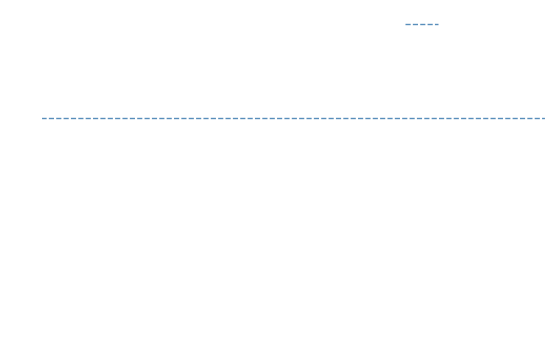

In [1]:
t = np.linspace(0, 8, 1000)
v = 3.0 + 1.0 * np.sin(2 * np.pi / 5.0 * t)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(t, v, color="white", lw=2)
ax.axhline(0, color="white", lw=0.7)
ax.axhline(3.0, color="steelblue", lw=1, ls="--", alpha=0.9, label="$V_{DC}=3$ V")
ax.set_xlabel("$t$ [μs]")
ax.set_ylabel("$V$", rotation=0, labelpad=10)
ax.set_xlim(0, 8)
ax.set_ylim(-0.3, 5.2)
ax.set_yticks([0, 2, 4])
ax.grid(True)
ax.legend(loc="upper right")

fig.tight_layout()
fig.savefig(OUT / "waveform_example.svg", **SAVE)
print("saved waveform_example.svg")

---

## AC + DC Decomposition

Shows that total signal = DC offset + AC component.

saved ac_dc_decomposition.svg


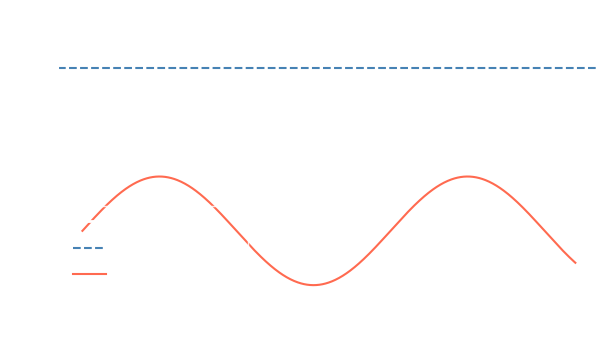

In [1]:
t = np.linspace(0, 8, 800)
ac = np.sin(2 * np.pi / 5 * t)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(t, 3.0 + ac, color="white", lw=2, label="Total signal")
ax.axhline(3.0, color="steelblue", lw=1.5, ls="--", label="DC offset")
ax.plot(t, ac, color="tomato", lw=1.5, alpha=0.95, label="AC component")
ax.set_xlabel("$t$")
ax.set_ylabel("Amplitude")
ax.legend()
ax.grid(True)

fig.tight_layout()
fig.savefig(OUT / "ac_dc_decomposition.svg", **SAVE)
print("saved ac_dc_decomposition.svg")